<a href="https://colab.research.google.com/github/hadil-ghazal/Regression-for-Churn-Interpretability/blob/main/Regression_for_Churn_Interpretability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regression for Churn Interpretability
**Hadil Ghazal 2026**

In [42]:
## No AI was used to generate this code, all code written by Hadil Ghazal on 9/4/26
# Library Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
# loading Telco Churn data

url = "https://raw.githubusercontent.com/hadil-ghazal/Regression-for-Churn-Interpretability/main/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(url)

#preview

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [44]:
# Data Elements Check (size, column names, data types, etc)
print(df.shape)
print(df.columns)
df.info()

(7043, 21)
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non

In [45]:
print(df["Churn"].value_counts())
print(df["TotalCharges"].unique()[:20])

Churn
No     5174
Yes    1869
Name: count, dtype: int64
['29.85' '1889.5' '108.15' '1840.75' '151.65' '820.5' '1949.4' '301.9'
 '3046.05' '3487.95' '587.45' '326.8' '5681.1' '5036.3' '2686.05'
 '7895.15' '1022.95' '7382.25' '528.35' '1862.9']


In [46]:
# Converting total charges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
# drop missing total charges rows
df = df.dropna(subset=["TotalCharges"])

# count after the drops
print(df.shape)

(7032, 21)


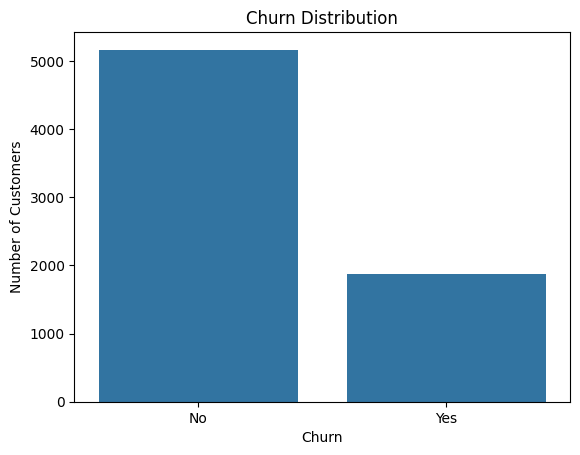

In [47]:
# Understanding the relationships between features and churn via plot distribution

sns.countplot(data=df, x="Churn")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

**Relational feature-churn observation 1:** the dataset is imbalanced and has more customers that didn't churn than customers that did

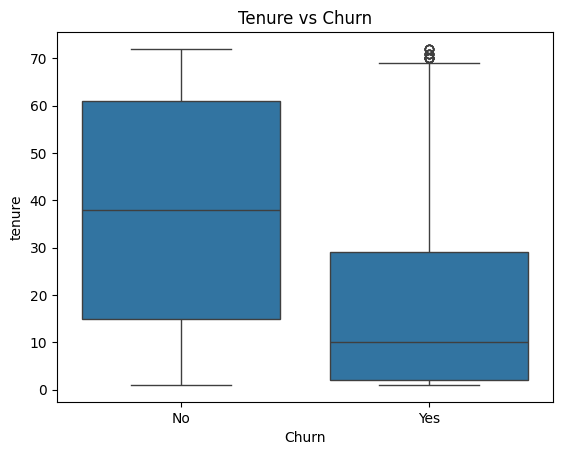

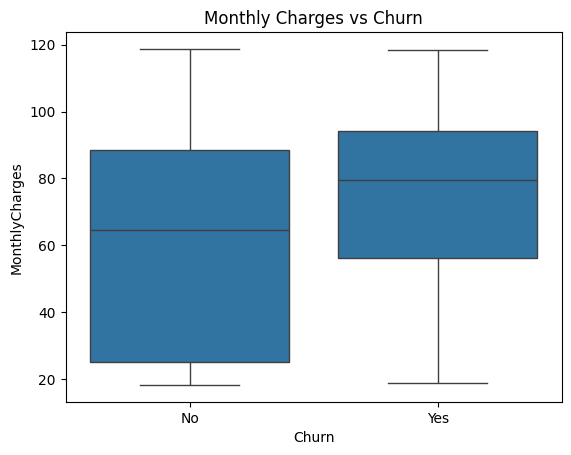

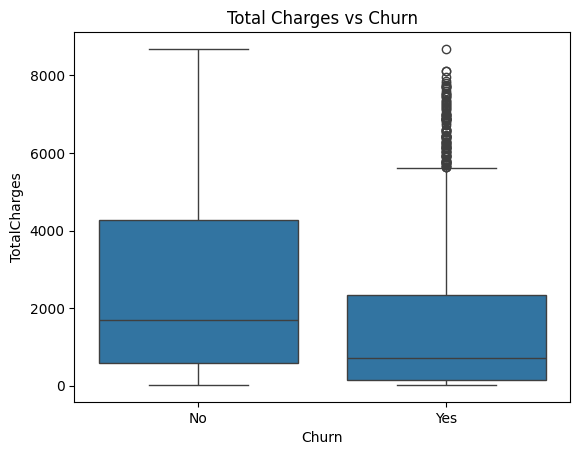

In [48]:
# Continuing analysis of feature relationships, numeric focus

# Tenure vs. Churn
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Tenure vs Churn")
plt.show()

# Monthly Charges vs. Churn
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges vs Churn")
plt.show()

# total Charges vs. Churn
sns.boxplot(data=df, x="Churn", y="TotalCharges")
plt.title("Total Charges vs Churn")
plt.show()

**Relational feature-churn observation 2:** Customers who churned had shorter tenure, and also higher monthly charges. Total charges were lower in customers who churned, probably related to them having short tenure

**LINEAR REGRESSION ASSUMPTIONS CHECK**

In [49]:
# numeric version for churn - regression
df["Churn_numeric"] = df["Churn"].map({"No": 0, "Yes": 1})

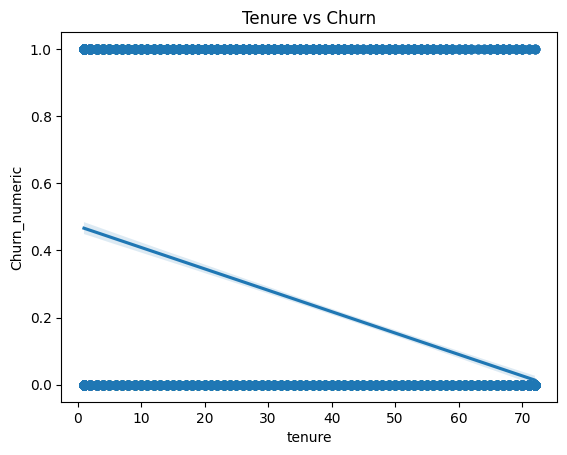

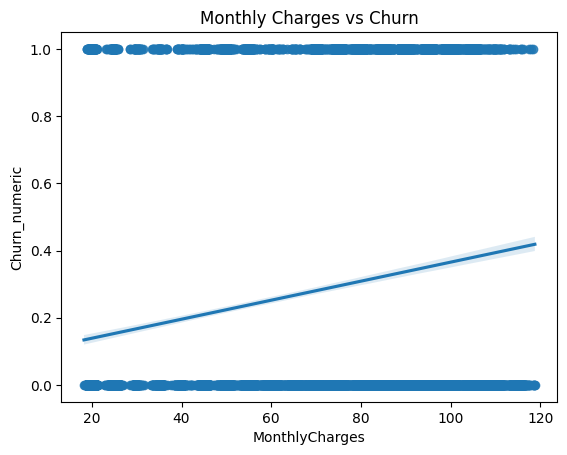

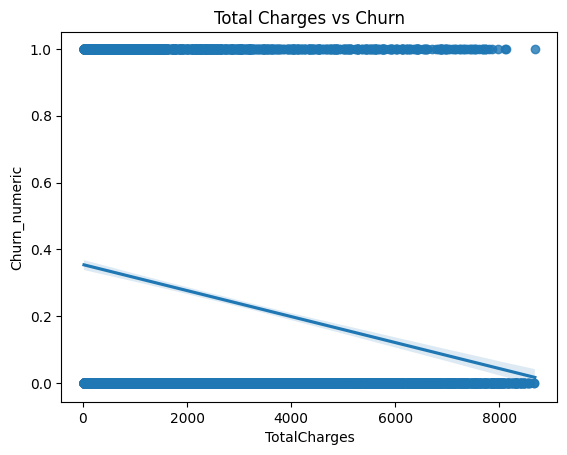

In [50]:
# Checking the relationship between churn and num

sns.regplot(data=df, x="tenure", y="Churn_numeric", logistic=False)
plt.title("Tenure vs Churn")
plt.show()


sns.regplot(data=df, x="MonthlyCharges", y="Churn_numeric", logistic=False)
plt.title("Monthly Charges vs Churn")
plt.show()

sns.regplot(data=df, x="TotalCharges", y="Churn_numeric", logistic=False)
plt.title("Total Charges vs Churn")
plt.show()

**Linear Observation:** The numeric features show theres directional relationships with churn. But, churn is binary, which limits the linear regression. THe residual plot also shows a nonrandom pattern, indicating that the linear regression assumptinos aren't satisfied

## Linear Regression

In [51]:
from sklearn import linear_model
# Importing for Linear Regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

#Using all features
# x = df[["tenure", "MonthlyCharges", "TotalCharges"]]
#y = df["Churn_numeric"]

x = df.drop(columns=["customerID", "Churn", "Churn_numeric"])
x = pd.get_dummies(x, drop_first=True)
y = df["Churn_numeric"]
print("Number of model features -", x.shape[1])

# Splitting data into testing and training sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Creating and training the linear regression model
linear_model = LinearRegression()
linear_model.fit(x_train, y_train)

# Making predictions on the test set
linear_predictions = linear_model.predict(x_test)

Number of model features - 30


**Evaluating Linear Regression**

In [57]:
# Evaluating the linear regression model
mse = mean_squared_error(y_test, linear_predictions)
r2 = r2_score(y_test, linear_predictions)

print("Mean Squared Error:", mse)
print("R-squared:", r2)

# Displaying model coefficients
for feature, coefficient in zip(x.columns, linear_model.coef_):
    print(f"{feature}: {coefficient}")

Mean Squared Error: 0.14593552097785367
R-squared: 0.25221407931758144
SeniorCitizen: 0.054640753184548724
tenure: -0.0018889299719291688
MonthlyCharges: -0.0036747769180303603
TotalCharges: -4.547204038535733e-05
gender_Male: -0.0036913036563686187
Partner_Yes: 0.007048454455733279
Dependents_Yes: -0.028448315208325466
PhoneService_Yes: 0.021362183045477733
MultipleLines_No phone service: -0.02136218304547785
MultipleLines_Yes: 0.068537469405781
InternetService_Fiber optic: 0.27353836701160866
InternetService_No: -0.03334219968910399
OnlineSecurity_No internet service: -0.03334219968910423
OnlineSecurity_Yes: -0.03718646261546805
OnlineBackup_No internet service: -0.0333421996891043
OnlineBackup_Yes: 0.007570754393632406
DeviceProtection_No internet service: -0.033342199689103826
DeviceProtection_Yes: 0.02153663436935214
TechSupport_No internet service: -0.03334219968910406
TechSupport_Yes: -0.037993704033039755
StreamingTV_No internet service: -0.033342199689104006
StreamingTV_Yes: 0

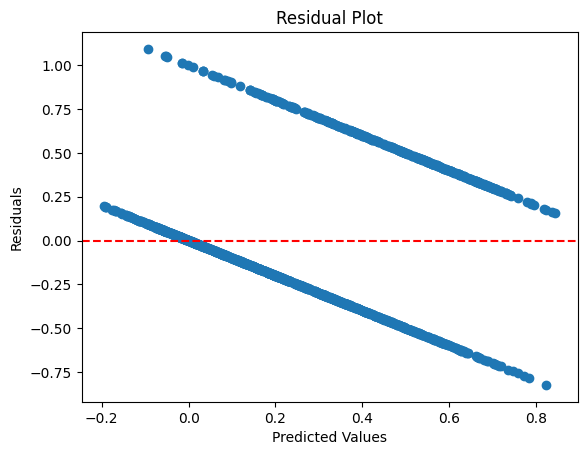

In [58]:
# Calculating residuals
residuals = y_test - linear_predictions

# Plotting residuals
plt.scatter(linear_predictions, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

**Residual Observation:** The residuals show as 2 distinct bands instead of random scatter. This shows that the linear regression doesn't fit well to this binary scenario

## Logistic Regression

In [62]:
# Importing Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Creating features and target
#X = df[["tenure", "MonthlyCharges", "TotalCharges"]]
#y = df["Churn_numeric"]

X = x
y = df["Churn_numeric"]

# running into convergence error, scaling the features
from sklearn.preprocessing import StandardScaler

X = X.copy()

scaler = StandardScaler()
X[["tenure", "MonthlyCharges", "TotalCharges"]] = scaler.fit_transform(X[["tenure", "MonthlyCharges", "TotalCharges"]])

# Splitting into testing / training data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creating and training the logistic model
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train, y_train)

# Making predictions on the test set
logistic_predictions = logistic_model.predict_proba(X_test)[:,1]

**Evaluating Logistic Regression**

In [63]:
# Importing evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# Make predictions
logistic_predictions = logistic_model.predict(X_test)

# Evaluating the model
accuracy = accuracy_score(y_test, logistic_predictions)
auc = roc_auc_score(y_test, logistic_predictions)
precision = precision_score(y_test, logistic_predictions)
recall = recall_score(y_test, logistic_predictions)

#Printing results
print("Accuracy:", accuracy)
print("ROC AUC:", auc)

for feature, coefficient in zip(X.columns, logistic_model.coef_[0]):
  print(feature, ":", coefficient)

Accuracy: 0.7867803837953091
ROC AUC: 0.6995692935274965
SeniorCitizen : 0.25995291445314433
tenure : -1.4452368605249815
MonthlyCharges : -0.28393556794184666
TotalCharges : 0.6887783600250206
gender_Male : -0.03268488025461486
Partner_Yes : 0.04955058194770484
Dependents_Yes : -0.21893858360426574
PhoneService_Yes : -0.5191870769916817
MultipleLines_No phone service : -0.09651050505206145
MultipleLines_Yes : 0.2675246503649413
InternetService_Fiber optic : 1.018843203551866
InternetService_No : -0.13916648005564658
OnlineSecurity_No internet service : -0.13916648005564658
OnlineSecurity_Yes : -0.39948557575039106
OnlineBackup_No internet service : -0.13916648005564658
OnlineBackup_Yes : -0.07343849576448977
DeviceProtection_No internet service : -0.13916648005564658
DeviceProtection_Yes : 0.024678559368674306
TechSupport_No internet service : -0.13916648005564658
TechSupport_Yes : -0.3743860308197148
StreamingTV_No internet service : -0.13916648005564658
StreamingTV_Yes : 0.321458981

**Logistic Regression Assumptions Check**

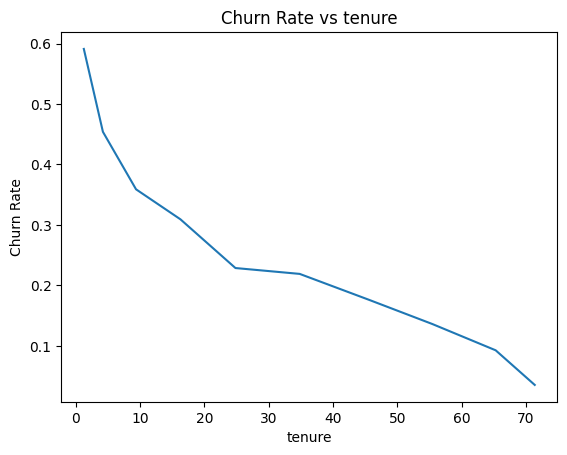

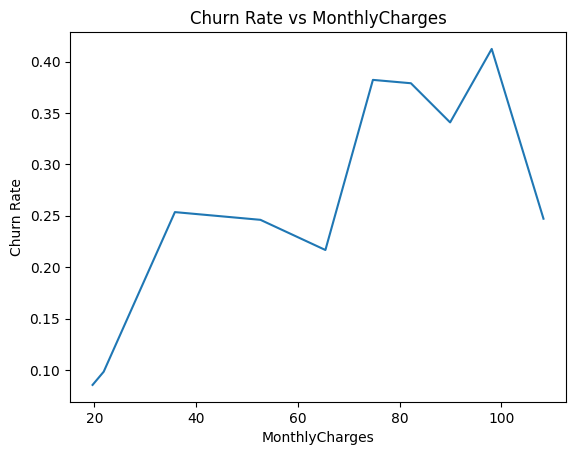

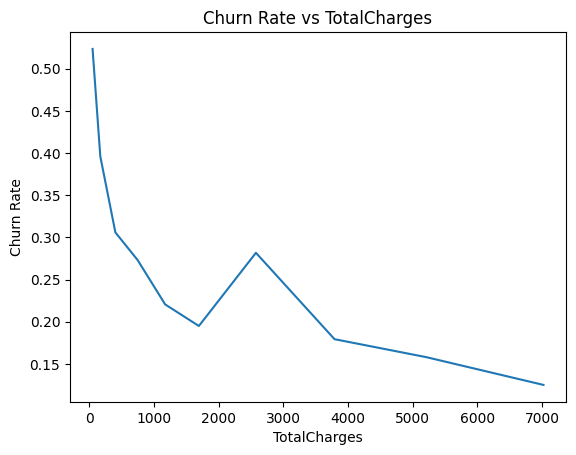

In [68]:
# Relationship check between the numeric features and churn

features = ["tenure", "MonthlyCharges", "TotalCharges"]

for feature in features:
    df["groups"] = pd.qcut(df[feature], q=10, duplicates="drop")
    churn_rate = df.groupby("groups", observed=True)[["Churn_numeric", feature]].mean()
    plt.plot(churn_rate[feature], churn_rate["Churn_numeric"])
    plt.xlabel(feature)
    plt.ylabel("Churn Rate")
    plt.title(f"Churn Rate vs {feature}")
    plt.show()
# Removing temp column
df = df.drop(columns="groups")

**Logistic Regression Assumption Observation:** There are solid relationships with chrun, but those patterns aren't completely linear. Monthly Charges and Total Charges show impact in direction, and show that the linearity assumption isn't a good fit.

##Generalized Additive Model (GAM)

In [69]:
#installing pyGAM
!pip install pygam -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 933.8 kB/s eta 0:00:00


In [70]:
from pygam import LogisticGAM, s, l

#feature check
for i, feature in enumerate(x.columns):
  print(i, feature)

0 SeniorCitizen
1 tenure
2 MonthlyCharges
3 TotalCharges
4 gender_Male
5 Partner_Yes
6 Dependents_Yes
7 PhoneService_Yes
8 MultipleLines_No phone service
9 MultipleLines_Yes
10 InternetService_Fiber optic
11 InternetService_No
12 OnlineSecurity_No internet service
13 OnlineSecurity_Yes
14 OnlineBackup_No internet service
15 OnlineBackup_Yes
16 DeviceProtection_No internet service
17 DeviceProtection_Yes
18 TechSupport_No internet service
19 TechSupport_Yes
20 StreamingTV_No internet service
21 StreamingTV_Yes
22 StreamingMovies_No internet service
23 StreamingMovies_Yes
24 Contract_One year
25 Contract_Two year
26 PaperlessBilling_Yes
27 PaymentMethod_Credit card (automatic)
28 PaymentMethod_Electronic check
29 PaymentMethod_Mailed check


In [71]:
# Creating GAM terms
terms = s(1) + s(2) + s(3)

# Linear terms for the remaining features
for i in [0] + list(range(4,30)):
  terms += l(i)

# Creating and training the GAM model
gam_model = LogisticGAM(terms)
gam_model.fit(x_train, y_train)

LogisticGAM(callbacks=[Deviance(), Diffs(), Accuracy()], 
   fit_intercept=True, max_iter=100, 
   terms=s(1) + s(2) + s(3) + l(0) + l(4) + l(5) + l(6) + l(7) + l(8) + l(9) + l(10) + l(11) + l(12) + l(13) + l(14) + l(15) + l(16) + l(17) + l(18) + l(19) + l(20) + l(21) + l(22) + l(23) + l(24) + l(25) + l(26) + l(27) + l(28) + l(29) + intercept,
   tol=0.0001, verbose=False)

In [72]:
# Making GAM predictions
gam_predictions = gam_model.predict(x_test)
gam_probabilities = gam_model.predict_proba(x_test)

# Evaluating the GAM
gam_accuracy = accuracy_score(y_test, gam_predictions)
gam_auc = roc_auc_score(y_test, gam_predictions)
gam_precision = precision_score(y_test, gam_predictions)
gam_recall = recall_score(y_test, gam_predictions)

# Printing GAM results
print("GAM Accuracy:", gam_accuracy)
print("GAM ROC AUC:", gam_auc)
print("GAM Precision:", gam_precision)
print("GAM Recall:", gam_recall)

GAM Accuracy: 0.7967306325515281
GAM ROC AUC: 0.7037870591341351
GAM Precision: 0.6517241379310345
GAM Recall: 0.5053475935828877


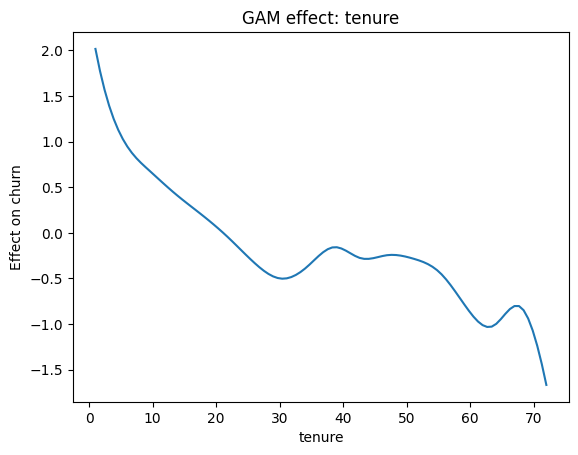

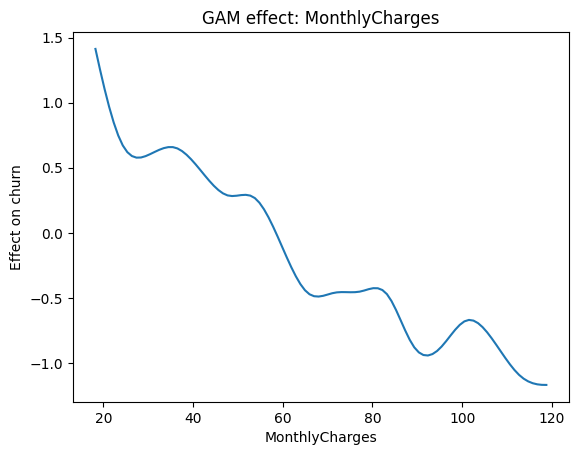

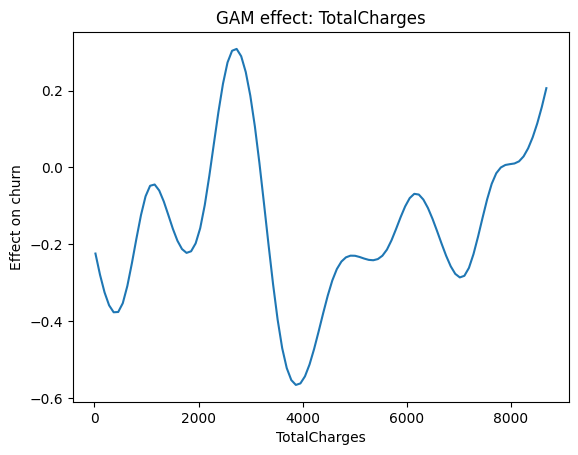

In [82]:
# Plotting GAM effects for the 3 features
features = {0: (1,"tenure"), 1: (2,"MonthlyCharges"), 2: (3, "TotalCharges")}
    #feature_names = list(features.values())

for term, (column, feature) in features.items():
  XX = gam_model.generate_X_grid(term=term)

  plt.plot(XX[:, column], gam_model.partial_dependence(term=term, X=XX))
  plt.xlabel(feature)
  plt.ylabel("Effect on churn")
  plt.title(f"GAM effect: {feature}")
  plt.show()

**GAM Observation:** This GAM shows nonlinear relationships between the features and churn. It appears that tenure has a decrease on churn, monthly charges / total charges on the other hand show varying patterns.Overall though, GAM captures the nuance that linear regression alone missed

## Model Comparison

In [87]:
# Comparing model performance across Linear regression, logistic regression, and GAM

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Logistic Regression", "GAM"],
    "Performance": [
        "MSE = 0.146, R2 = 0.252",
        "Accuracy = 0.787, ROC AUC = 0.700",
        "Accuracy = 0.797, ROC AUC = 0.704"
    ]
})
comparison

,Model,Performance
0,Linear Regression,"MSE = 0.146, R2 = 0.252"
1,Logistic Regression,"Accuracy = 0.787, ROC AUC = 0.700"
2,GAM,"Accuracy = 0.797, ROC AUC = 0.704"


**Model Comparison Analysis:** Linear regression is easiest to interpret but is the weakest in this use case. Logistic Regression is a good balance, where it is easier than GAM to interpret but still has good accuracy. GAM had the highest accuracy and ROC AUC, but trickier to interpret. If the company assessing the best model fit can justify the boost in accuracy via long term customer retention and revenue stick, then that is the best fit. If the cost of largely implementing and maintaining the GAM would outpace the potential churn save, then Logistic regression is a better fit.